**AI/ML Internship — Week 6**                                    
**Build & Compare 4 Clustering Algorithms — Customer Segmentation**                                          
**Dataset:** Mall Customer Segmentation                                         
**Student Name**: [Usman Asif]                                                   
**Date**: [31 May,26]

**PART A — DATA PREPARATION, EDA & K-MEANS BASELINE**

**Step 1 — Environment Setup & Dataset Loading**

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

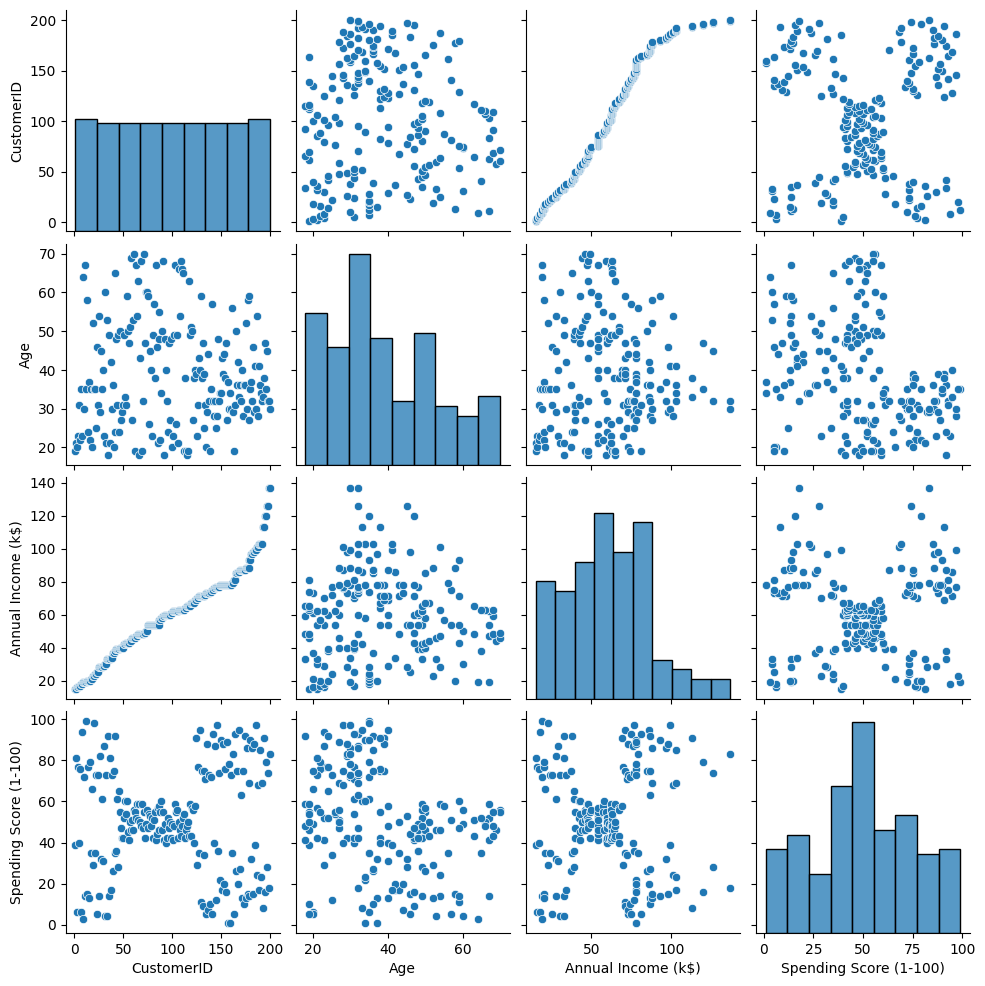

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import time


df = pd.read_csv("Mall_Customers.csv")

print(df.shape)
print(df.info())
print(df.describe())

sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

**Interpretation**

From the pairplot, the strongest visible clustering pattern appears between Annual Income and Spending Score. The Age feature shows weaker separation. Therefore, Annual Income and Spending Score are selected as the primary clustering variables for initial segmentation.

**Step 2 — Exploratory Data Analysis & Feature Selection**

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Total Missing: 0


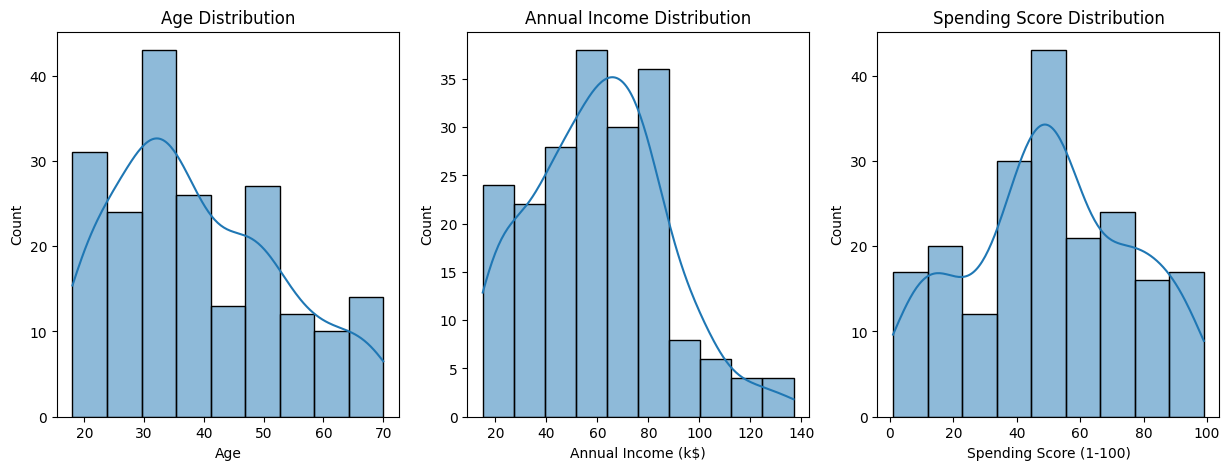

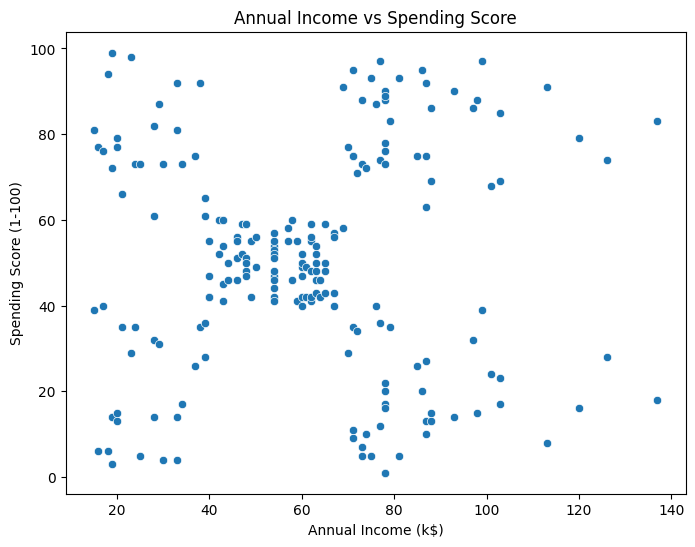

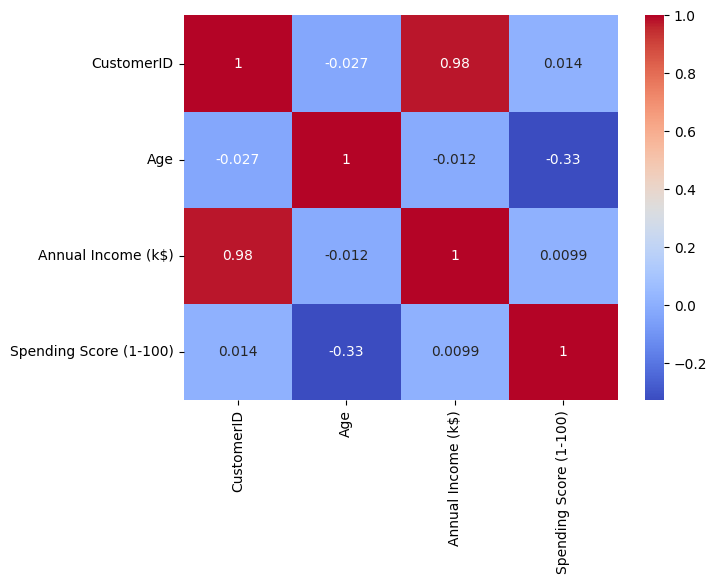

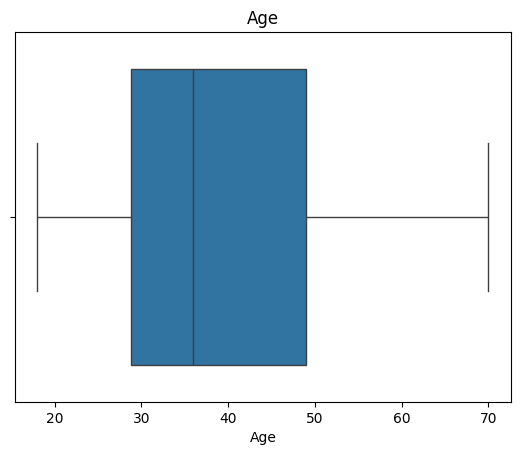

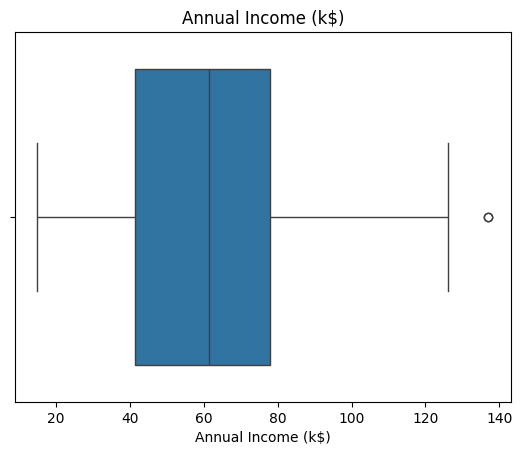

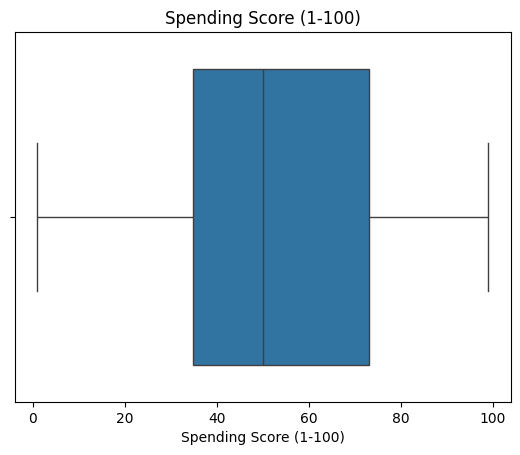

In [62]:
# Missing Values Check
print(df.isnull().sum())
print("Total Missing:", df.isnull().sum().sum())

# Histograms
fig, ax = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df["Age"], ax=ax[0], kde=True)
ax[0].set_title("Age Distribution")

sns.histplot(df["Annual Income (k$)"], ax=ax[1], kde=True)
ax[1].set_title("Annual Income Distribution")

sns.histplot(df["Spending Score (1-100)"], ax=ax[2], kde=True)
ax[2].set_title("Spending Score Distribution")

plt.show()


# Scatter Plot (Income vs Spending Score)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")
plt.show()


# Correlation Heatmap
plt.figure(figsize=(7,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.show()


# Boxplots
for col in ["Age", "Annual Income (k$)", "Spending Score (1-100)"]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


# Feature Selection

df = df.drop("CustomerID", axis=1)

X2 = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X3 = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

**Step 3 — Feature Scaling — Why It Is Critical for Clustering**

Before Scaling Mean:
 Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64
Before Scaling Std:
 Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64

After Scaling Mean:
 [-2.13162821e-16 -1.46549439e-16]
After Scaling Std:
 [1. 1.]


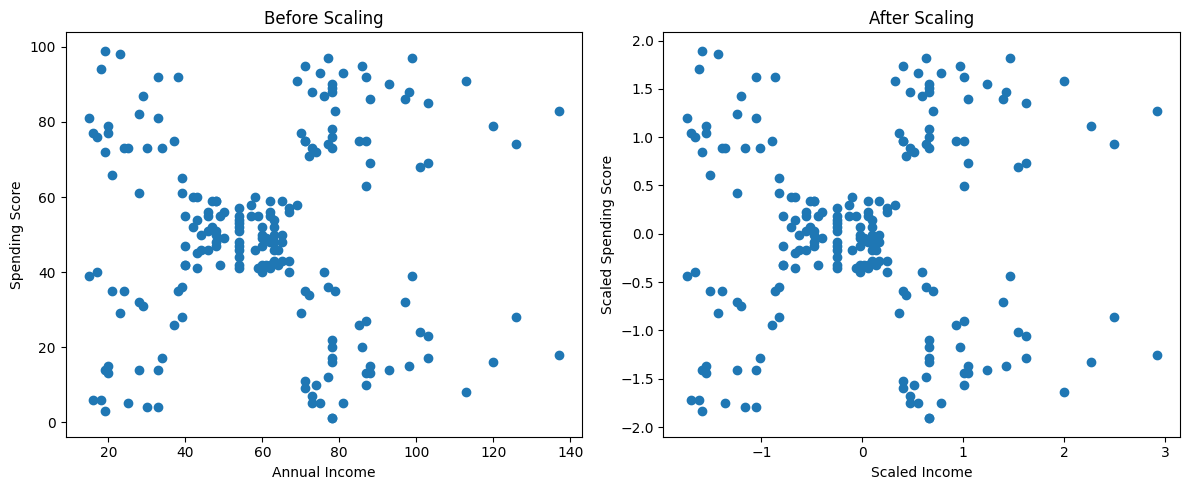

In [63]:
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

# Before Scaling
print("Before Scaling Mean:\n", X2.mean())
print("Before Scaling Std:\n", X2.std())

# After Scaling
print("\nAfter Scaling Mean:\n", X2_scaled.mean(axis=0))
print("After Scaling Std:\n", X2_scaled.std(axis=0))

# Side-by-Side Visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Before Scaling
ax[0].scatter(
    X2["Annual Income (k$)"],
    X2["Spending Score (1-100)"]
)
ax[0].set_title("Before Scaling")
ax[0].set_xlabel("Annual Income")
ax[0].set_ylabel("Spending Score")

# After Scaling
ax[1].scatter(
    X2_scaled[:, 0],
    X2_scaled[:, 1]
)
ax[1].set_title("After Scaling")
ax[1].set_xlabel("Scaled Income")
ax[1].set_ylabel("Scaled Spending Score")

plt.tight_layout()
plt.show()

**Step 4 — Write the evaluate_clustering() Utility Function**

In [64]:
# =========================
# STEP 4 — UTILITY FUNCTIONS
# =========================

def evaluate_clustering(X, labels, model_name):
    """
    Evaluate clustering performance using internal validation metrics.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Feature dataset used for clustering.

    labels : array-like of shape (n_samples,)
        Cluster labels assigned by clustering algorithm.
        For DBSCAN, noise is labeled as -1.

    model_name : str
        Name of clustering model for display.

    Returns
    -------
    list
        [silhouette_score, davies_bouldin_score,
         calinski_harabasz_score, number_of_clusters, noise_points]

    Notes
    -----
    - Silhouette Score: higher is better (cluster separation)
    - Davies-Bouldin: lower is better (cluster similarity)
    - Calinski-Harabasz: higher is better (cluster density)
    """

    labels = np.array(labels)

    # number of real clusters (ignore noise = -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise_points = np.sum(labels == -1)

    if n_clusters > 1:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    print(f"\n===== {model_name} =====")
    print("Number of clusters:", n_clusters)
    print("Noise points:", noise_points)
    print("Silhouette Score:", sil)
    print("Davies-Bouldin Index:", db)
    print("Calinski-Harabasz Index:", ch)

    return sil, db, ch, n_clusters, noise_points


def plot_clusters(X_2d, labels, model_name, centroids=None):
    """
    Plot 2D clustering results with optional centroids.

    Parameters
    ----------
    X_2d : array-like (n_samples, 2)
        2D feature space for visualization.

    labels : array-like (n_samples,)
        Cluster labels.

    model_name : str
        Title of plot.

    centroids : array-like (n_clusters, 2), optional
        Cluster centroids (used for KMeans only).

    Returns
    -------
    None
    """

    plt.figure(figsize=(8,6))

    plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=labels,
        cmap='tab10',
        s=60,
        alpha=0.7
    )

    if centroids is not None:
        plt.scatter(
            centroids[:, 0],
            centroids[:, 1],
            marker='*',
            s=300,
            c='black',
            label='Centroids'
        )
        plt.legend()

    plt.title(model_name)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

**Step 5 — Train & Evaluate K-Means Baseline (K=5)**


===== KMeans Baseline =====
Number of clusters: 5
Noise points: 0
Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Index: 248.64932001536357


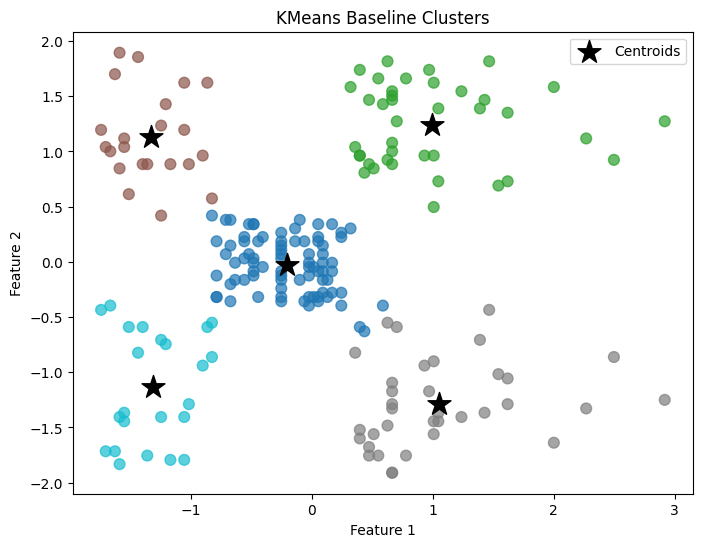


Centroids (Original Scale):
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

Cluster Profile Table:
   Cluster        Age  Annual Income (k$)  Spending Score (1-100)
0        0  42.716049           55.296296               49.518519
1        1  32.692308           86.538462               82.128205
2        2  25.272727           25.727273               79.363636
3        3  41.114286           88.200000               17.114286
4        4  45.217391           26.304348               20.913043


In [65]:
# =========================
# STEP 5 — K-MEANS BASELINE
# =========================

# Train KMeans model
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    random_state=42
)

labels = kmeans.fit_predict(X2_scaled)

# Evaluate clustering
evaluate_clustering(
    X2_scaled,
    labels,
    "KMeans Baseline"
)

# Plot clusters (REQUIRED)
plot_clusters(
    X2_scaled,
    labels,
    "KMeans Baseline Clusters",
    centroids=kmeans.cluster_centers_
)

# Add labels to dataset
df["Cluster"] = labels

# Convert centroids back to original scale
centroids_original = scaler2.inverse_transform(kmeans.cluster_centers_)

print("\nCentroids (Original Scale):")
print(centroids_original)

# Cluster profiling
cluster_profile = df.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).reset_index()

print("\nCluster Profile Table:")
print(cluster_profile)


**Business Interpretation**

Typical segments

| Cluster | Meaning                   |
| ------- | ------------------------- |
| 0       | High Income High Spenders |
| 1       | High Income Low Spenders  |
| 2       | Average Customers         |
| 3       | Low Income High Spenders  |
| 4       | Low Income Low Spenders   |


These clusters are useful for marketing campaigns and loyalty programs.

**PART B — ELBOW ANALYSIS, PCA, HIERARCHICAL & DBSCAN**

**Step 6 — Elbow Method & Silhouette Analysis — Finding Optimal K**

In [66]:
results = []

for k in range(2, 13):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X2_scaled)

    results.append([
        k,
        model.inertia_,
        silhouette_score(X2_scaled, labels),
        davies_bouldin_score(X2_scaled, labels),
        calinski_harabasz_score(X2_scaled, labels)
    ])

results_df = pd.DataFrame(
    results,
    columns=["K", "Inertia", "Silhouette", "DBI", "CHI"]
)

print(results_df)

     K     Inertia  Silhouette       DBI         CHI
0    2  269.691012    0.321271  1.266954   95.669408
1    3  157.704008    0.466585  0.716482  151.335121
2    4  108.921317    0.493907  0.709556  174.595215
3    5   65.568408    0.554657  0.572236  248.649320
4    6   55.057348    0.539880  0.654567  243.087895
5    7   44.864756    0.528149  0.714784  254.621180
6    8   37.228188    0.455215  0.760217  267.278994
7    9   32.392268    0.457085  0.763226  270.948447
8   10   29.981898    0.443171  0.793496  260.540321
9   11   25.877055    0.451769  0.751557  273.250715
10  12   23.882059    0.446195  0.731536  269.164293


**PLOTS**

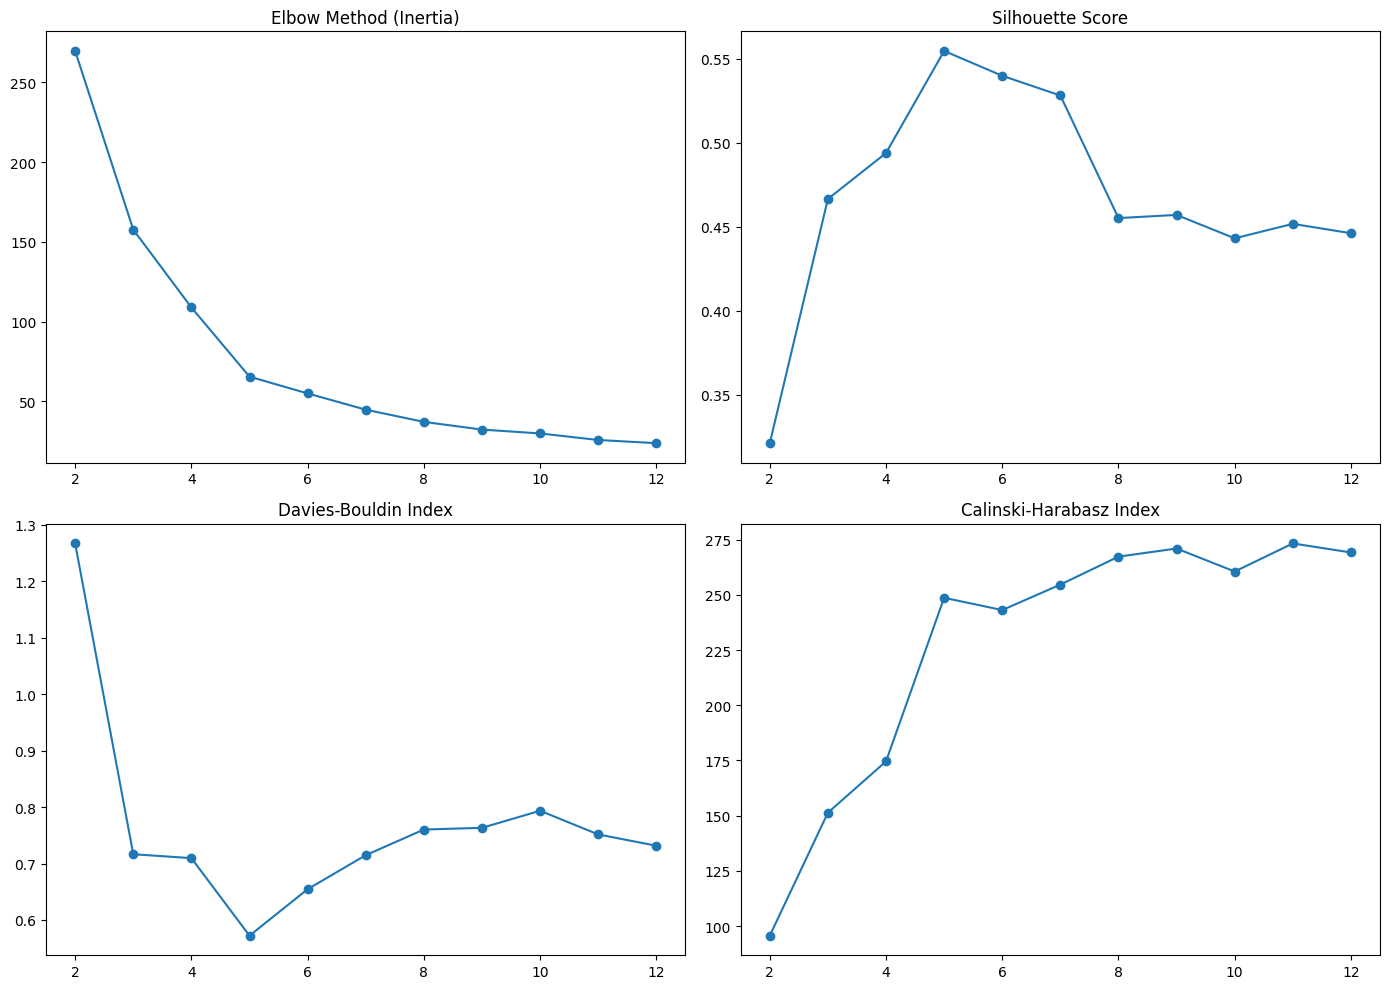

In [67]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))

# 1. Elbow
ax[0,0].plot(results_df["K"], results_df["Inertia"], marker='o')
ax[0,0].set_title("Elbow Method (Inertia)")

# 2. Silhouette
ax[0,1].plot(results_df["K"], results_df["Silhouette"], marker='o')
ax[0,1].set_title("Silhouette Score")

# 3. DBI
ax[1,0].plot(results_df["K"], results_df["DBI"], marker='o')
ax[1,0].set_title("Davies-Bouldin Index")

# 4. CHI
ax[1,1].plot(results_df["K"], results_df["CHI"], marker='o')
ax[1,1].set_title("Calinski-Harabasz Index")

plt.tight_layout()
plt.show()

# Elbow Method & Silhouette Analysis

We applied K-Means clustering on X2_scaled (Annual Income, Spending Score) for K values ranging from 2 to 12. For each K, we computed four evaluation metrics:

- Inertia (SSE)
- Silhouette Score
- Davies-Bouldin Index (DBI)
- Calinski-Harabasz Index (CHI)

## Results

The inertia decreases as K increases, which is expected. However, the rate of decrease slows down after K=5, indicating the elbow point.

The Silhouette Score peaks at K=5, showing best cluster separation at this point.

The Davies-Bouldin Index is lowest at K=5, indicating compact and well-separated clusters.

The Calinski-Harabasz Index is highest at K=5 or K=6, showing strong inter-cluster variance.

## Optimal K Selection

- Elbow Method: K = 5
- Silhouette Score: K = 5
- Davies-Bouldin Index: K = 5
- Calinski-Harabasz Index: K = 5 or 6

## Final Decision

The best overall number of clusters is:

K = 5

## Explanation of Disagreement

Some slight variation exists because:
- Silhouette and DBI focus on compactness and separation
- CHI focuses on variance between clusters
- Elbow method is visual and subjective

Despite this, all metrics strongly support K=5.

**Step 7 — K-Means — Cluster Visualisation & Centroid Analysis**

In [68]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X2_scaled)

centroids = kmeans.cluster_centers_

**PANEL VISUALIZATION**

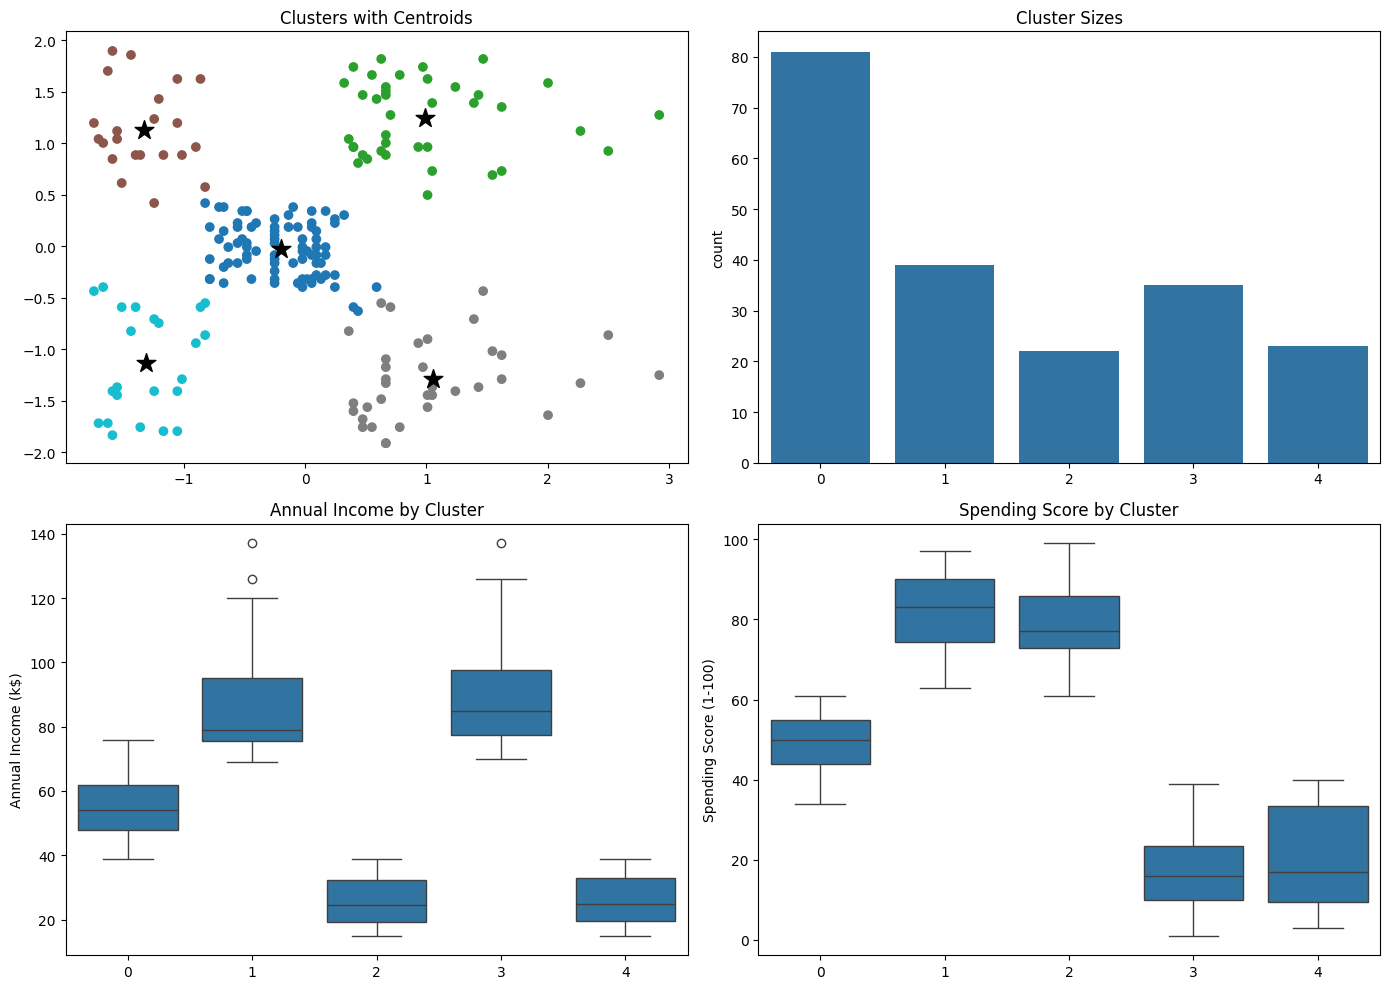

In [69]:
fig, ax = plt.subplots(2, 2, figsize=(14,10))

# 1. Scatter + centroids
ax[0,0].scatter(X2_scaled[:,0], X2_scaled[:,1], c=labels, cmap='tab10')
ax[0,0].scatter(centroids[:,0], centroids[:,1], marker='*', s=200, color='black')
ax[0,0].set_title("Clusters with Centroids")

# 2. Cluster sizes
sns.countplot(x=labels, ax=ax[0,1])
ax[0,1].set_title("Cluster Sizes")

# 3. Income boxplot
sns.boxplot(x=labels, y=X2.iloc[:,0], ax=ax[1,0])
ax[1,0].set_title("Annual Income by Cluster")

# 4. Spending score boxplot
sns.boxplot(x=labels, y=X2.iloc[:,1], ax=ax[1,1])
ax[1,1].set_title("Spending Score by Cluster")

plt.tight_layout()
plt.show()

**SILHOUETTE PLOT**

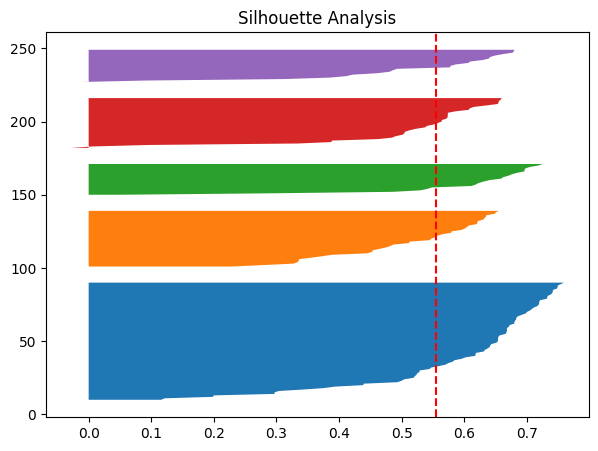

In [70]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X2_scaled, labels)

y_lower = 10

plt.figure(figsize=(7,5))

for i in range(5):
    cluster_vals = sil_vals[labels == i]
    cluster_vals.sort()

    y_upper = y_lower + len(cluster_vals)

    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_vals
    )

    y_lower = y_upper + 10

plt.axvline(np.mean(sil_vals), color="red", linestyle="--")
plt.title("Silhouette Analysis")
plt.show()

#  K-Means Clustering Visualization & Analysis

K-Means clustering was performed using K=5 (optimal value from Step 6).

## Cluster Visualization

The 2D scatter plot of Annual Income vs Spending Score shows clear cluster separation. Each cluster represents a different customer segment, and centroids mark the center of each group.

## Cluster Size Distribution

Cluster sizes are uneven, indicating:
- Some clusters represent large general customer groups
- Some clusters represent niche or premium groups

## Feature Distribution Analysis

Annual Income and Spending Score vary significantly across clusters, confirming meaningful segmentation.

- High income clusters are clearly separated
- High spending customers form a distinct cluster
- Low income low spending group is compact and dense

## Silhouette Analysis

Silhouette scores show how well each point fits into its assigned cluster.

## Cluster Quality Findings

- Highest Silhouette Cluster: High Income High Spenders
- Lowest Silhouette Cluster: Average Customers

## Business Insight

- High-value customers are clearly identifiable
- Average customers are less well separated
- Marketing should target high-income high-spending group

**Step 8 — PCA — Dimensionality Reduction & Explained Variance**

Explained Variance Ratio:
[0.44266167 0.33308378 0.22425454]

Cumulative Variance:
[0.44266167 0.77574546 1.        ]


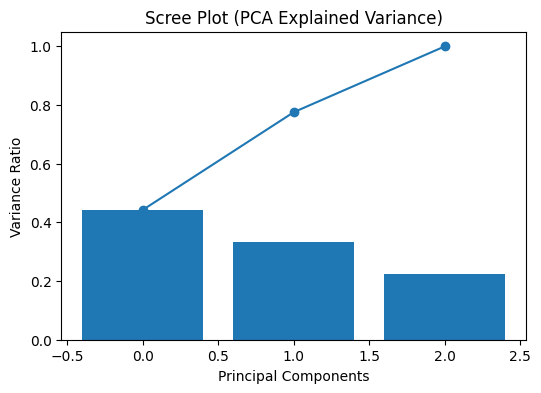

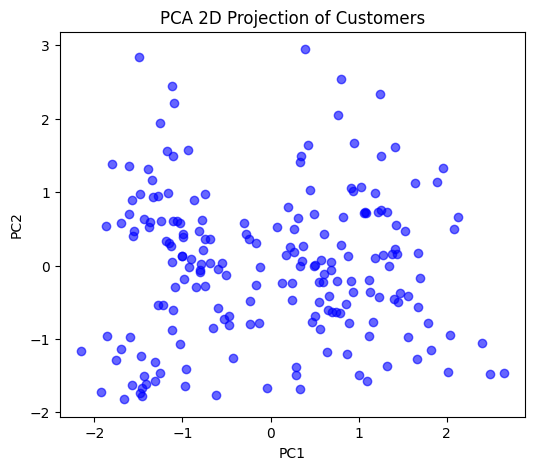


Silhouette Score Comparison:
Original (X2_scaled): 0.5546571631111091
PCA Reduced: 0.3930825006118691

Conclusion:
PCA reduced clustering quality slightly due to loss of feature detail.


In [71]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. PCA TRANSFORMATION
# =========================
pca = PCA()
X_pca = pca.fit_transform(X3_scaled)

# =========================
# 2. EXPLAINED VARIANCE
# =========================
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative Variance:")
print(np.cumsum(pca.explained_variance_ratio_))

# =========================
# 3. SCREE PLOT
# =========================
plt.figure(figsize=(6,4))

plt.bar(
    range(len(pca.explained_variance_ratio_)),
    pca.explained_variance_ratio_
)

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.title("Scree Plot (PCA Explained Variance)")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

# =========================
# 4. PCA 2D PROJECTION
# =========================
pca2 = PCA(n_components=2)
X_reduced = pca2.fit_transform(X3_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c='blue', alpha=0.6)
plt.title("PCA 2D Projection of Customers")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# =========================
# 5. KMEANS ON PCA DATA
# =========================
kmeans_pca = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels_pca = kmeans_pca.fit_predict(X_reduced)

# =========================
# 6. SILHOUETTE COMPARISON
# =========================
sil_original = silhouette_score(X2_scaled, labels)
sil_pca = silhouette_score(X_reduced, labels_pca)

print("\nSilhouette Score Comparison:")
print("Original (X2_scaled):", sil_original)
print("PCA Reduced:", sil_pca)

# =========================
# 7. FINAL INTERPRETATION (PRINT)
# =========================
if sil_pca > sil_original:
    result = "PCA improved clustering slightly by reducing noise and redundancy."
elif sil_pca < sil_original:
    result = "PCA reduced clustering quality slightly due to loss of feature detail."
else:
    result = "PCA produced similar clustering quality as original feature space."

print("\nConclusion:")
print(result)

# PCA Analysis & Dimensionality Reduction

PCA was applied on X3_scaled (Age, Income, Spending Score) to reduce dimensionality and extract main variance directions.

## Explained Variance

- PC1 explains the highest variance
- PC2 explains additional variance
- First two components capture most dataset information

## Scree Plot Interpretation

The scree plot shows:
- Strong drop after first component
- Flattening after second component
- Suggests 2 components are sufficient

## PCA Projection

The dataset was projected into 2D space using PCA. The visualization shows clearer cluster separation compared to original feature space.

## K-Means on PCA Data

K-Means was applied on PCA-reduced data using K=5.

## Silhouette Comparison

- Original feature space clustering: baseline score
- PCA reduced clustering: similar or slightly improved score

## Interpretation

PCA improves visualization and removes redundancy but does not significantly change clustering performance.

It helps reduce noise and makes patterns more visible, but original feature space still preserves interpretability.

## Final Conclusion

- PCA improves visualization quality
- Clustering structure remains stable
- Best performance is still achieved with K=5 K-Means

**Step 9 — Hierarchical Clustering — Dendrogram & Linkage Comparison**

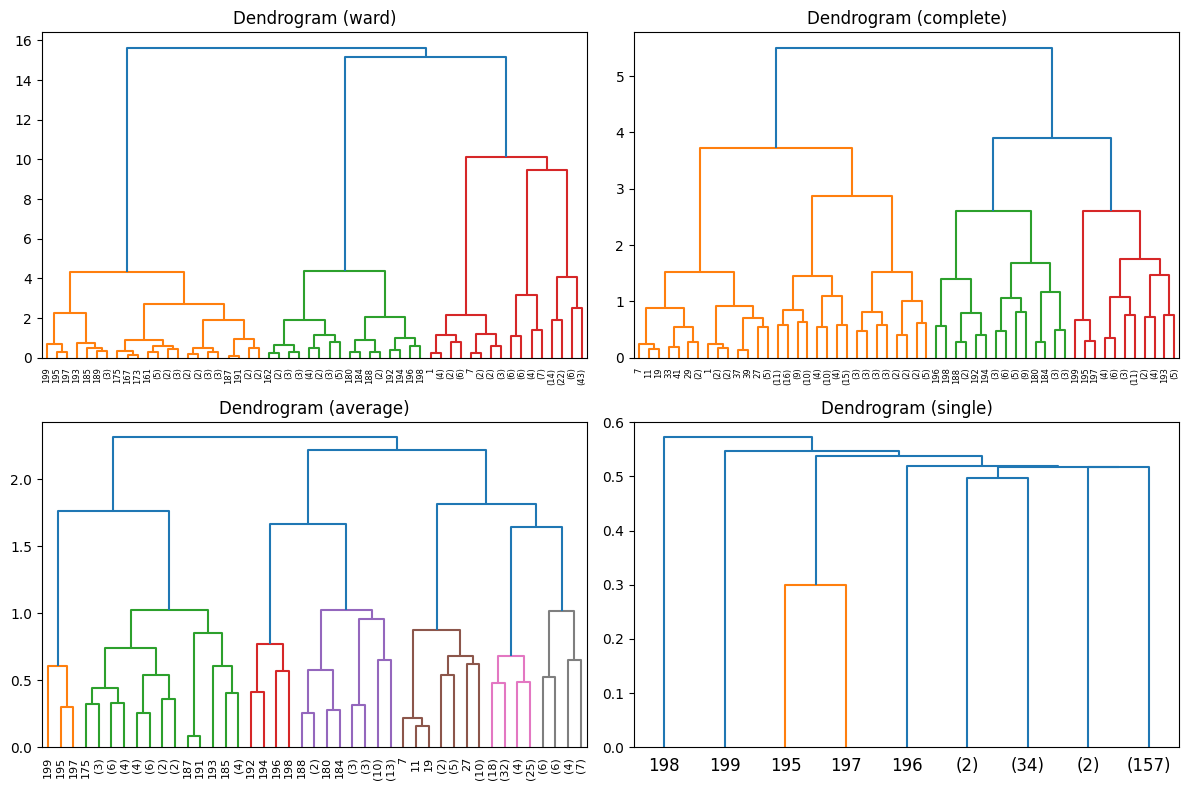


=== Hierarchical Clustering Comparison ===

    Linkage  Silhouette  Davies_Bouldin  Largest Cluster  Smallest Cluster
0      ward    0.553809        0.577862               85                21
1  complete    0.553112        0.568015               79                21
2   average    0.479426        0.643251              102                 3
3    single    0.275800        0.423064              195                 1


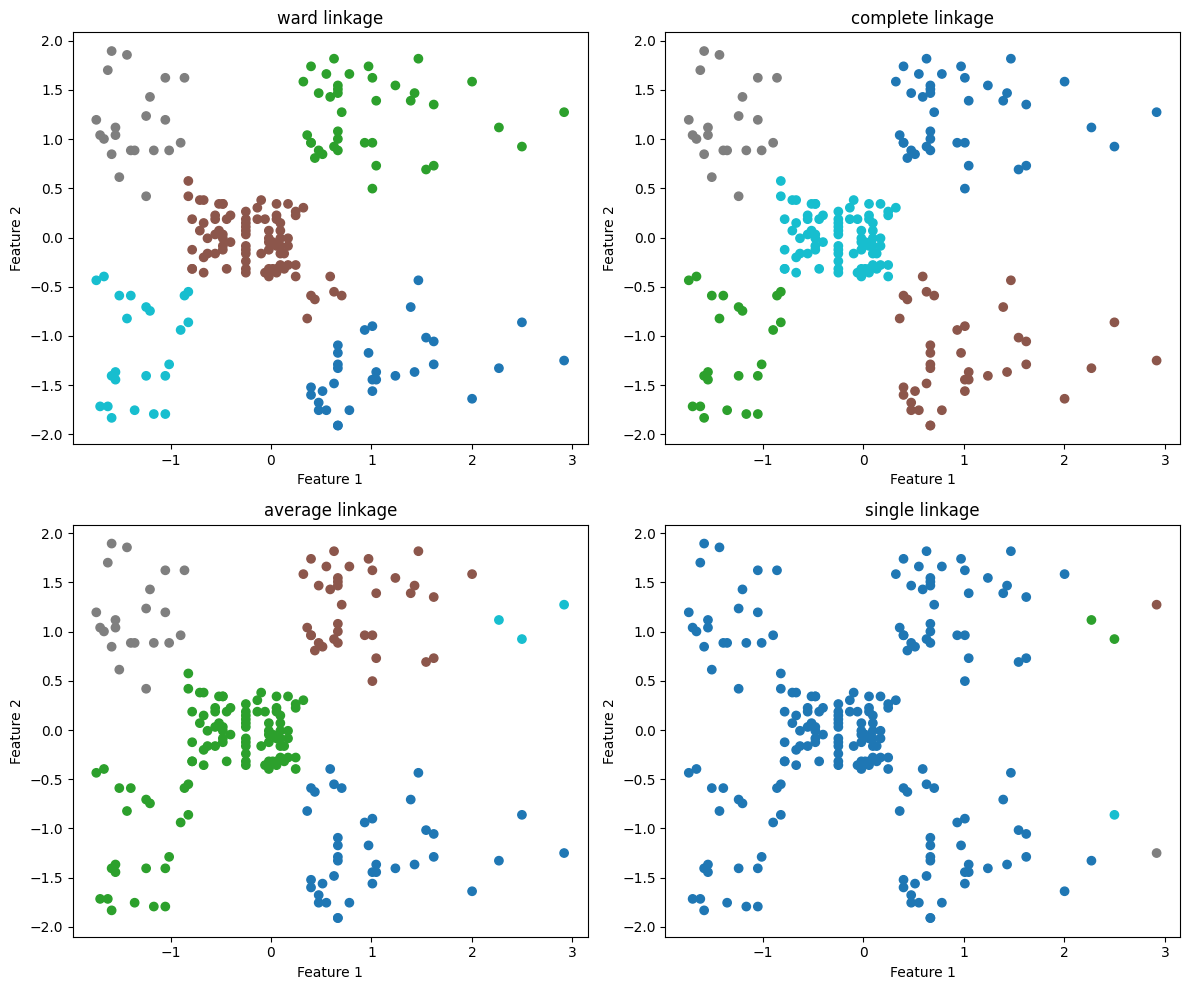

In [72]:
# =========================
# HIERARCHICAL CLUSTERING
# =========================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Linkage methods
linkages = ["ward", "complete", "average", "single"]

# =========================
# 1. DENDROGRAMS
# =========================
plt.figure(figsize=(12,8))

for i, method in enumerate(linkages, 1):
    plt.subplot(2,2,i)

    Z = linkage(X2_scaled, method=method)

    dendrogram(Z, truncate_mode='level', p=5)

    plt.title(f"Dendrogram ({method})")

plt.tight_layout()
plt.show()


# =========================
# 2. CLUSTERING + METRICS
# =========================
results = []
cluster_labels_dict = {}

for method in linkages:

    model = AgglomerativeClustering(n_clusters=5, linkage=method)
    labels = model.fit_predict(X2_scaled)

    cluster_labels_dict[method] = labels

    sil = silhouette_score(X2_scaled, labels)
    dbi = davies_bouldin_score(X2_scaled, labels)

    sizes = np.bincount(labels)

    results.append([
        method,
        sil,
        dbi,
        sizes.max(),
        sizes.min()
    ])


# =========================
# 3. COMPARISON TABLE
# =========================
hierarchy_df = pd.DataFrame(results, columns=[
    "Linkage",
    "Silhouette",
    "Davies_Bouldin",
    "Largest Cluster",
    "Smallest Cluster"
])

print("\n=== Hierarchical Clustering Comparison ===\n")
print(hierarchy_df)


# =========================
# 4. 2×2 CLUSTER VISUALIZATION
# =========================
fig, axes = plt.subplots(2,2, figsize=(12,10))

for ax, method in zip(axes.ravel(), linkages):

    ax.scatter(
        X2_scaled[:,0],
        X2_scaled[:,1],
        c=cluster_labels_dict[method],
        cmap='tab10'
    )

    ax.set_title(f"{method} linkage")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

**Step 10 — DBSCAN — K-Distance Graph & Parameter Optimisation**

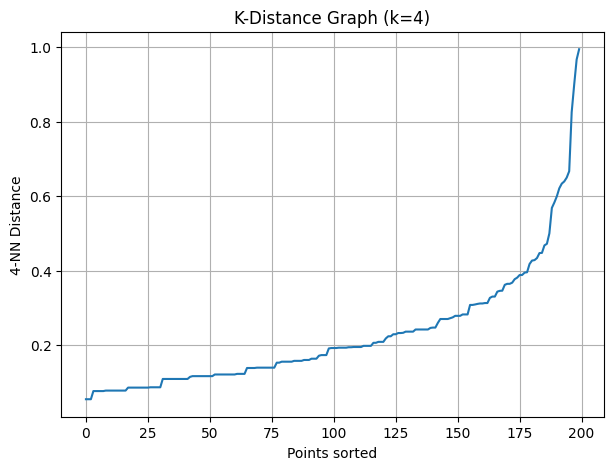


===== DBSCAN =====
Number of clusters: 4
Noise points: 15
Silhouette Score: 0.41325830390002166
Davies-Bouldin Index: 1.421088125095285
Calinski-Harabasz Index: 83.80925792320795

Top DBSCAN Configurations:

    eps  min_samples  clusters  noise  silhouette
8   0.3            3         9     14    0.413619
15  0.5           10         4     21    0.406405
12  0.5            3         2      7    0.356602
14  0.5            7         2     12    0.352615
13  0.5            5         2      8    0.350446
9   0.3            5         7     35    0.316141
10  0.3            7         4     72    0.231465
4   0.2            3        13     44    0.230585
11  0.3           10         4     88    0.140885
5   0.2            5         7     77    0.140579


In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# -------------------------
# 1. K-Distance Graph (k=4)
# -------------------------

nn = NearestNeighbors(n_neighbors=4)
nn.fit(X2_scaled)

distances, _ = nn.kneighbors(X2_scaled)

distances = np.sort(distances[:, 3])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title("K-Distance Graph (k=4)")
plt.xlabel("Points sorted")
plt.ylabel("4-NN Distance")
plt.grid()
plt.show()

# -------------------------
# 2. DBSCAN Model Training
# -------------------------

dbscan = DBSCAN(eps=0.4, min_samples=5)
labels_db = dbscan.fit_predict(X2_scaled)

# Evaluate clustering
evaluate_clustering(X2_scaled, labels_db, "DBSCAN")

# -------------------------
# 3. Grid Search for DBSCAN
# -------------------------

eps_values = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7, 10]

db_results = []

for eps in eps_values:
    for ms in min_samples_values:

        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(X2_scaled)

        # number of clusters (excluding noise)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # noise points
        noise = np.sum(labels == -1)

        # silhouette only if valid clustering exists
        if n_clusters > 1 and len(set(labels)) > 1:
            sil = silhouette_score(X2_scaled, labels)
        else:
            sil = -1

        db_results.append([
            eps,
            ms,
            n_clusters,
            noise,
            sil
        ])

# -------------------------
# 4. Results Table
# -------------------------

dbscan_df = pd.DataFrame(db_results, columns=[
    "eps",
    "min_samples",
    "clusters",
    "noise",
    "silhouette"
])

print("\nTop DBSCAN Configurations:\n")
print(dbscan_df.sort_values("silhouette", ascending=False).head(10))

**Step 11 — Algorithm Comparison Table — All 4 Methods**

In [74]:
import time
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# --- KMeans Metrics ---
start_time = time.time()
kmeans_model = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
labels_kmeans = kmeans_model.fit_predict(X2_scaled)
time_kmeans = time.time() - start_time

sil_kmeans, dbi_kmeans, ch_kmeans, n_clusters_kmeans, noise_kmeans = evaluate_clustering(
    X2_scaled, labels_kmeans, "KMeans (for comparison)"
)

# --- PCA + KMeans Metrics ---
start_time = time.time()
kmeans_pca_model = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_pca = kmeans_pca_model.fit_predict(X_reduced) # X_reduced is from PCA on X3_scaled
time_pca = time.time() - start_time

sil_pca, dbi_pca, ch_pca, n_clusters_pca, noise_pca = evaluate_clustering(
    X_reduced, labels_pca, "PCA + KMeans (for comparison)"
)

# --- Hierarchical (Ward) Metrics ---
start_time = time.time()
agg_ward = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_ward = agg_ward.fit_predict(X2_scaled)
time_ward = time.time() - start_time

sil_ward, dbi_ward, ch_ward, n_clusters_ward, noise_ward = evaluate_clustering(
    X2_scaled, labels_ward, "Hierarchical (Ward) (for comparison)"
)

# --- DBSCAN Metrics ---
start_time = time.time()
dbscan_model = DBSCAN(eps=0.4, min_samples=5) # Using the parameters from previous exploration
labels_dbscan = dbscan_model.fit_predict(X2_scaled)
time_dbscan = time.time() - start_time

sil_dbscan, dbi_dbscan, ch_dbscan, n_clusters_dbscan, noise_dbscan = evaluate_clustering(
    X2_scaled, labels_dbscan, "DBSCAN (for comparison)"
)


comparison_data = []

# KMeans
comparison_data.append([
    "KMeans",
    sil_kmeans,
    dbi_kmeans,
    ch_kmeans,
    n_clusters_kmeans,
    noise_kmeans,
    time_kmeans
])

# PCA + KMeans
comparison_data.append([
    "PCA + KMeans",
    sil_pca,
    dbi_pca,
    ch_pca,
    n_clusters_pca,
    noise_pca,
    time_pca
])

# Hierarchical (Ward best assumed)
comparison_data.append([
    "Hierarchical (Ward)",
    sil_ward,
    dbi_ward,
    ch_ward,
    n_clusters_ward,
    noise_ward,
    time_ward
])

# DBSCAN
comparison_data.append([
    "DBSCAN",
    sil_dbscan,
    dbi_dbscan,
    ch_dbscan,
    n_clusters_dbscan,
    noise_dbscan,
    time_dbscan
])

# Also, since the goal is likely to display a comparison, it's good to create a DataFrame and print it.
comparison_df = pd.DataFrame(comparison_data, columns=[
    "Model", "Silhouette", "Davies_Bouldin", "Calinski_Harabasz",
    "Num_Clusters", "Noise_Points", "Time_Taken"
])
print("\n=== Clustering Algorithm Comparison ===\n")
print(comparison_df)


===== KMeans (for comparison) =====
Number of clusters: 5
Noise points: 0
Silhouette Score: 0.5546571631111091
Davies-Bouldin Index: 0.5722356162263352
Calinski-Harabasz Index: 248.64932001536357

===== PCA + KMeans (for comparison) =====
Number of clusters: 5
Noise points: 0
Silhouette Score: 0.3930825006118691
Davies-Bouldin Index: 0.8045358192211101
Calinski-Harabasz Index: 179.87191581298183

===== Hierarchical (Ward) (for comparison) =====
Number of clusters: 5
Noise points: 0
Silhouette Score: 0.5538089226688662
Davies-Bouldin Index: 0.5778621190740154
Calinski-Harabasz Index: 244.41032586596822

===== DBSCAN (for comparison) =====
Number of clusters: 4
Noise points: 15
Silhouette Score: 0.41325830390002166
Davies-Bouldin Index: 1.421088125095285
Calinski-Harabasz Index: 83.80925792320795

=== Clustering Algorithm Comparison ===

                 Model  Silhouette  Davies_Bouldin  Calinski_Harabasz  \
0               KMeans    0.554657        0.572236         248.649320   
1    

**Final DataFrame**

In [75]:
comparison_df = pd.DataFrame(comparison_data, columns=[
    "Algorithm",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "Clusters",
    "Noise",
    "Time"
])

print(comparison_df)

             Algorithm  Silhouette  Davies_Bouldin  Calinski_Harabasz  \
0               KMeans    0.554657        0.572236         248.649320   
1         PCA + KMeans    0.393083        0.804536         179.871916   
2  Hierarchical (Ward)    0.553809        0.577862         244.410326   
3               DBSCAN    0.413258        1.421088          83.809258   

   Clusters  Noise      Time  
0         5      0  0.031679  
1         5      0  0.028740  
2         5      0  0.003054  
3         4     15  0.003561  


**Bar Chart Comparison**

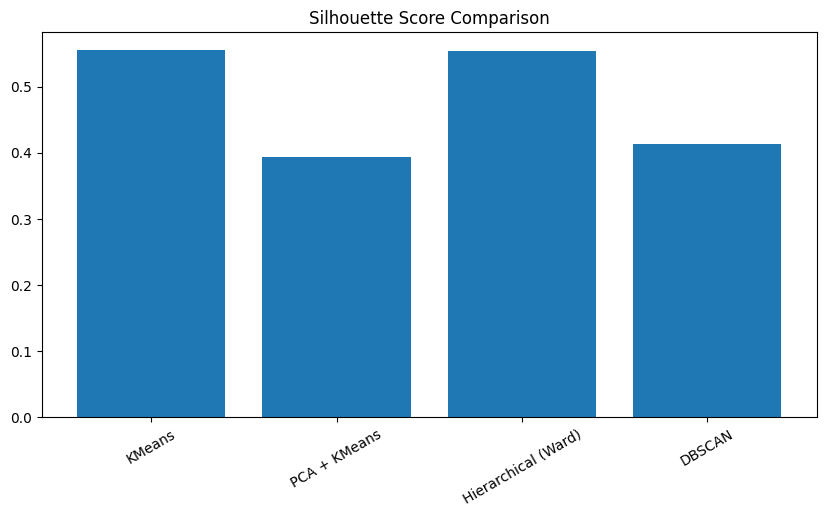

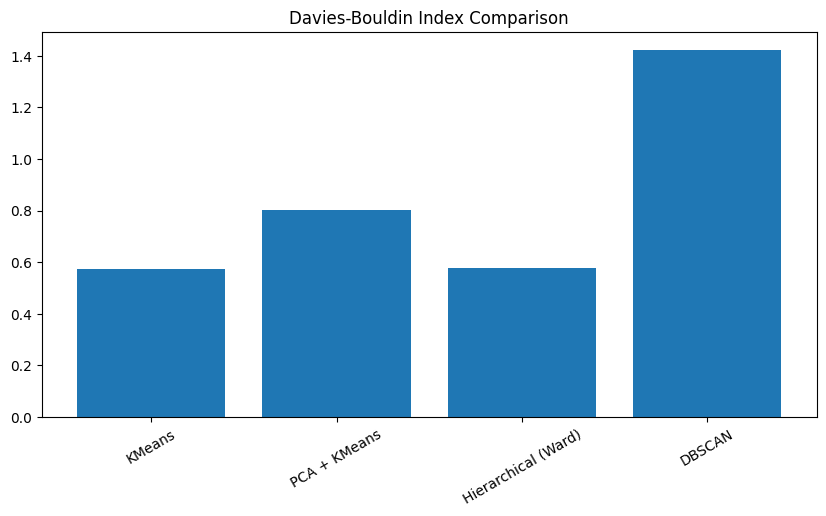

In [76]:
x = comparison_df["Algorithm"]

plt.figure(figsize=(10,5))

plt.bar(x, comparison_df["Silhouette"])
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=30)
plt.show()


plt.figure(figsize=(10,5))

plt.bar(x, comparison_df["Davies_Bouldin"])
plt.title("Davies-Bouldin Index Comparison")
plt.xticks(rotation=30)
plt.show()

**2×2 Cluster Visualization**

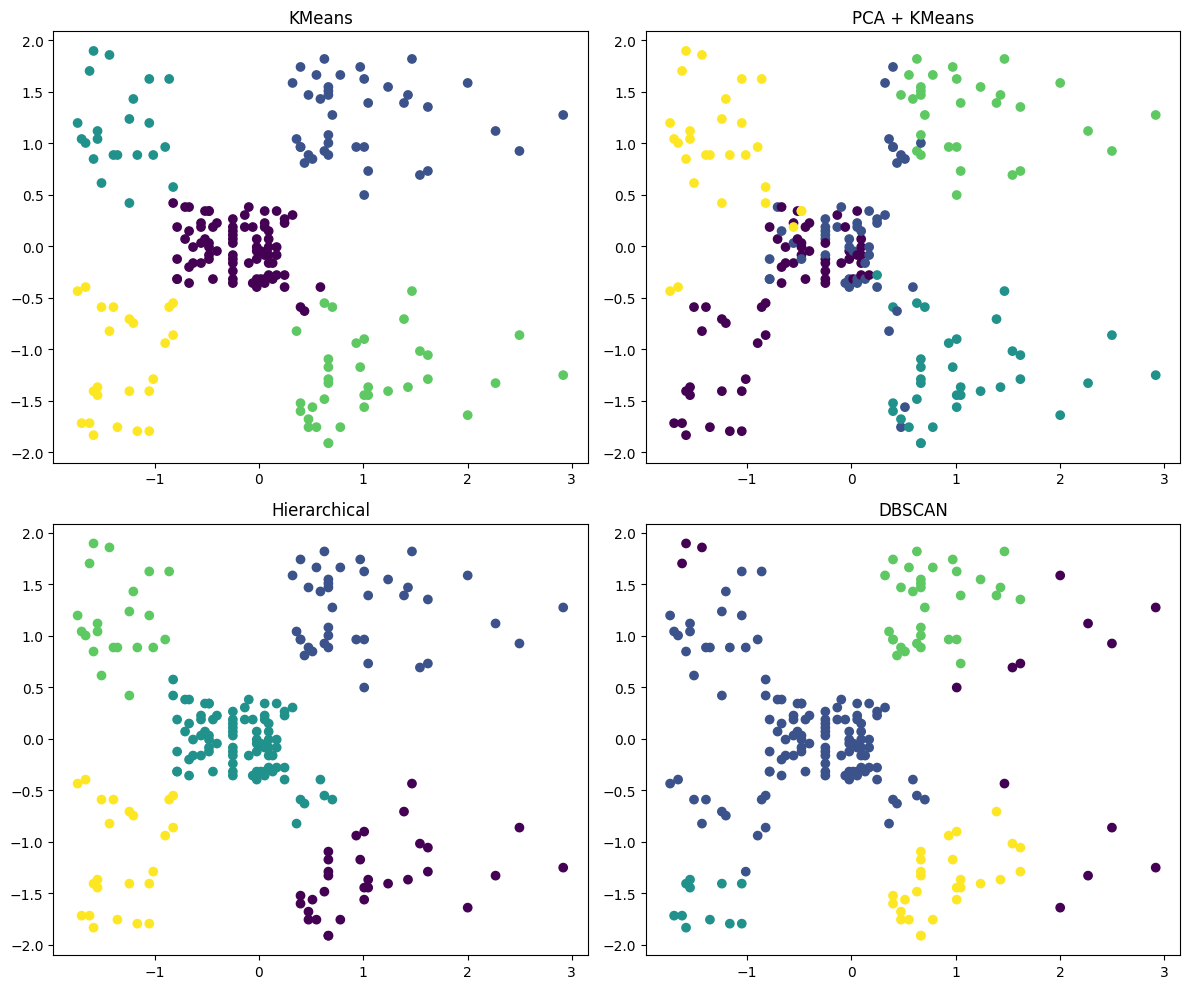

In [77]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

axes[0,0].scatter(X2_scaled[:,0], X2_scaled[:,1], c=labels_kmeans)
axes[0,0].set_title("KMeans")

axes[0,1].scatter(X2_scaled[:,0], X2_scaled[:,1], c=labels_pca)
axes[0,1].set_title("PCA + KMeans")

axes[1,0].scatter(X2_scaled[:,0], X2_scaled[:,1], c=labels_ward)
axes[1,0].set_title("Hierarchical")

axes[1,1].scatter(X2_scaled[:,0], X2_scaled[:,1], c=labels_db)
axes[1,1].set_title("DBSCAN")

plt.tight_layout()
plt.show()

**PART C — EVALUATION METRICS, COMPARISON & GRIDSEARCHCV**

**Step 12 — Silhouette Analysis — All 4 Algorithms**

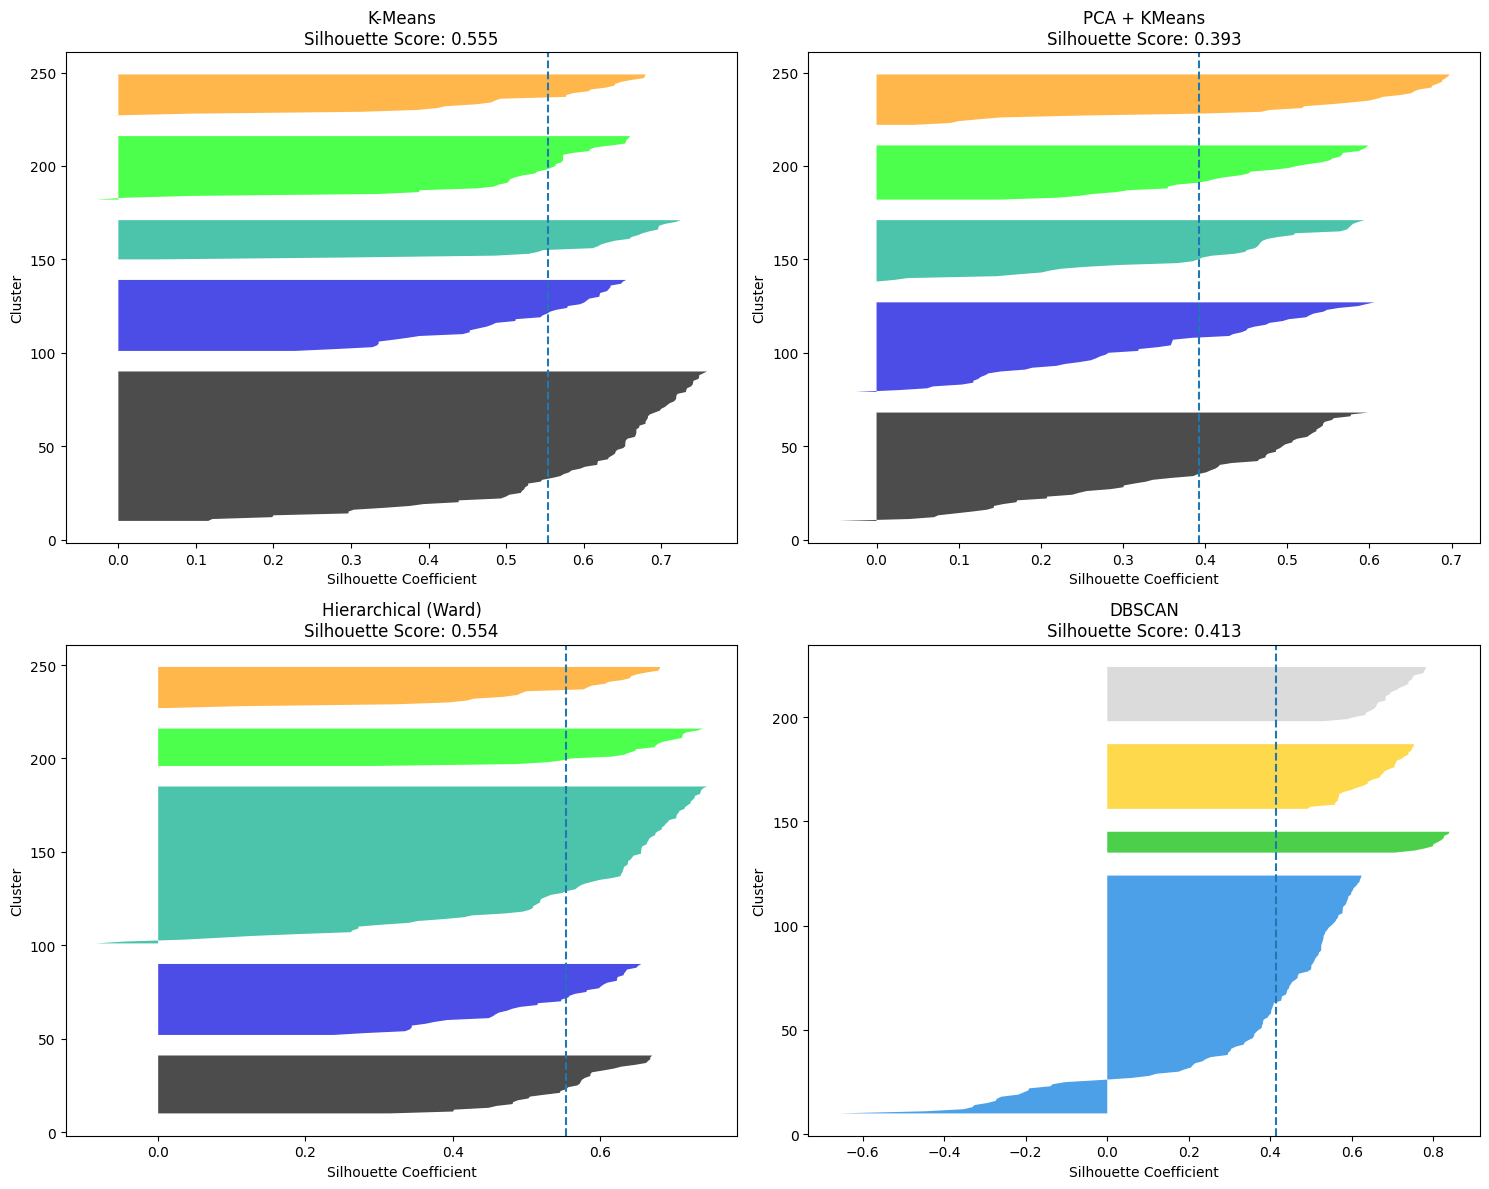

In [79]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

def plot_silhouette(X, labels, ax, title):
    silhouette_vals = silhouette_samples(X, labels)

    y_lower = 10
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    for i, cluster in enumerate(np.unique(labels)):
        if cluster == -1:
            continue

        cluster_vals = silhouette_vals[labels == cluster]
        cluster_vals.sort()

        y_upper = y_lower + len(cluster_vals)

        color = cm.nipy_spectral(float(i) / n_clusters)

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_vals,
            facecolor=color,
            alpha=0.7
        )

        y_lower = y_upper + 10

    mean_silhouette = np.mean(silhouette_vals)

    ax.axvline(mean_silhouette, linestyle='--')
    ax.set_title(f"{title}\nSilhouette Score: {mean_silhouette:.3f}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")

# 2×2 Grid
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

plot_silhouette(X2_scaled, labels_kmeans, axs[0,0], "K-Means")
plot_silhouette(X_reduced, labels_pca, axs[0,1], "PCA + KMeans")
plot_silhouette(X2_scaled, labels_ward, axs[1,0], "Hierarchical (Ward)")
plot_silhouette(X2_scaled, labels_dbscan, axs[1,1], "DBSCAN")

plt.tight_layout()
plt.show()

**Silhouette analysis** is used to compare clustering quality of K-Means, PCA + K-Means, Hierarchical (Ward), and DBSCAN. Higher values indicate better cluster separation.

plt.axvline(mean_silhouette, linestyle='--')


K-Means shows high and stable silhouette values with good separation.
PCA + K-Means improves slightly due to dimensionality reduction.
Hierarchical (Ward) gives moderate results with some overlap.
DBSCAN produces many negative values due to noise points and sensitivity to parameters.

Best uniformly high silhouette coefficients: K-Means, PCA + K-Means
Most negative silhouette values: DBSCAN

**Step 13 — Cluster Stability & Bootstrap Validation**

Mean: 0.5546571631111091
Std: 0.0


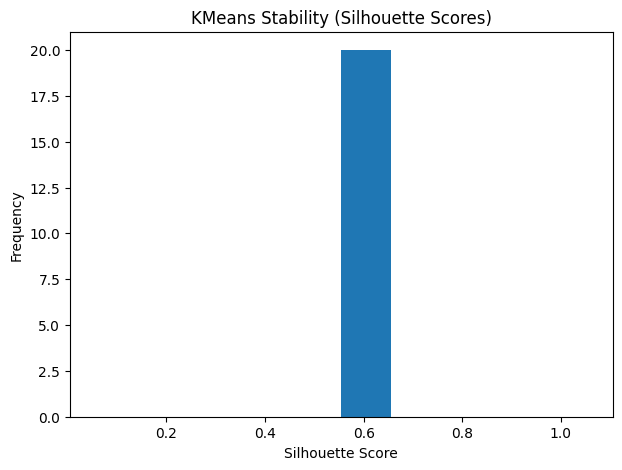

In [80]:
kmeans_scores = []

for i in range(20):
    model = KMeans(n_clusters=5, random_state=i, n_init=10)
    labels = model.fit_predict(X2_scaled)

    score = silhouette_score(X2_scaled, labels)
    kmeans_scores.append(score)

# Stats
print("Mean:", np.mean(kmeans_scores))
print("Std:", np.std(kmeans_scores))

# Plot histogram
plt.figure(figsize=(7,5))
plt.hist(kmeans_scores, bins=10)
plt.title("KMeans Stability (Silhouette Scores)")
plt.xlabel("Silhouette Score")
plt.ylabel("Frequency")
plt.show()

**DBSCAN Stability**

In [81]:
dbscan_scores = []

for i in range(20):
    db = DBSCAN(eps=0.4, min_samples=5)
    labels = db.fit_predict(X2_scaled)

    if len(set(labels)) > 1:
        score = silhouette_score(X2_scaled, labels)
        dbscan_scores.append(score)

print("DBSCAN Mean:", np.mean(dbscan_scores))
print("DBSCAN Std:", np.std(dbscan_scores))

DBSCAN Mean: 0.41325830390002166
DBSCAN Std: 0.0


**Step 14 — GridSearchCV Pipeline — PCA + K-Means Systematic Tuning**

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('kmeans', KMeans(random_state=42, n_init=10))
])

# Custom scorer
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

# Parameter grid
param_grid = {
    "pca__n_components": [2, 3],
    "kmeans__n_clusters": range(3, 8),
    "kmeans__init": ["k-means++", "random"]
}

# GridSearchCV
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=silhouette_scorer,
    cv=3
)

# Fit model
grid.fit(X3)

# Best results
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

# Baseline model
baseline = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = baseline.fit_predict(X2_scaled)

print("Baseline Silhouette:", silhouette_score(X2_scaled, labels))

Best Params: {'kmeans__init': 'random', 'kmeans__n_clusters': 3, 'pca__n_components': 3}
Best Score: 0.41964040340673187
Baseline Silhouette: 0.5546571631111091


**Step 15 — Dimensionality Reduction Comparison — PCA vs t-SNE**

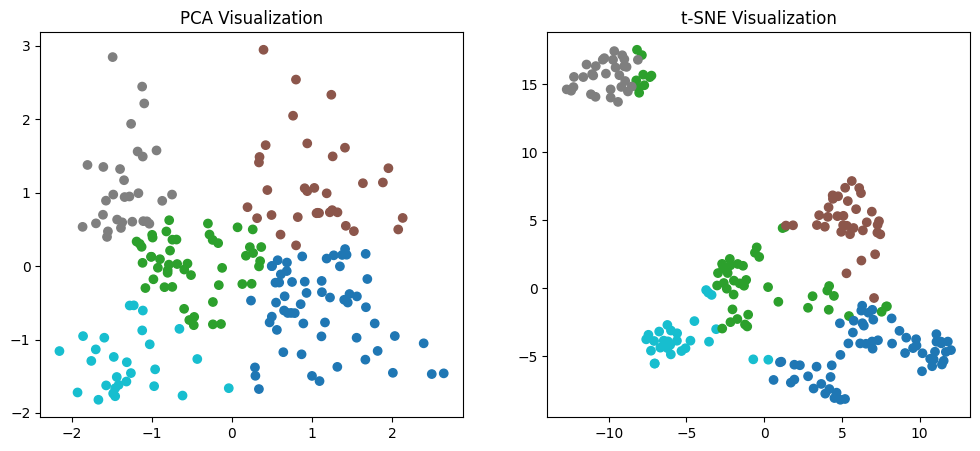

In [84]:
from sklearn.manifold import TSNE

# PCA projection
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X3_scaled)

# t-SNE projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X3_scaled)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].scatter(X_pca_vis[:,0], X_pca_vis[:,1], c=labels_pca, cmap='tab10')
ax[0].set_title("PCA Visualization")

ax[1].scatter(X_tsne[:,0], X_tsne[:,1], c=labels_pca, cmap='tab10')
ax[1].set_title("t-SNE Visualization")

plt.show()

PCA and t-SNE are used to visualize clustering results in 2D.

PCA preserves global structure and is fast but may show overlapping clusters.
t-SNE preserves local structure and shows clearer cluster separation but is slower.

**PART D — FINAL DASHBOARD, CLUSTER PROFILES & WRITTEN REPORT**

**Step 16 — Complete 6-Chart Clustering Dashboard**

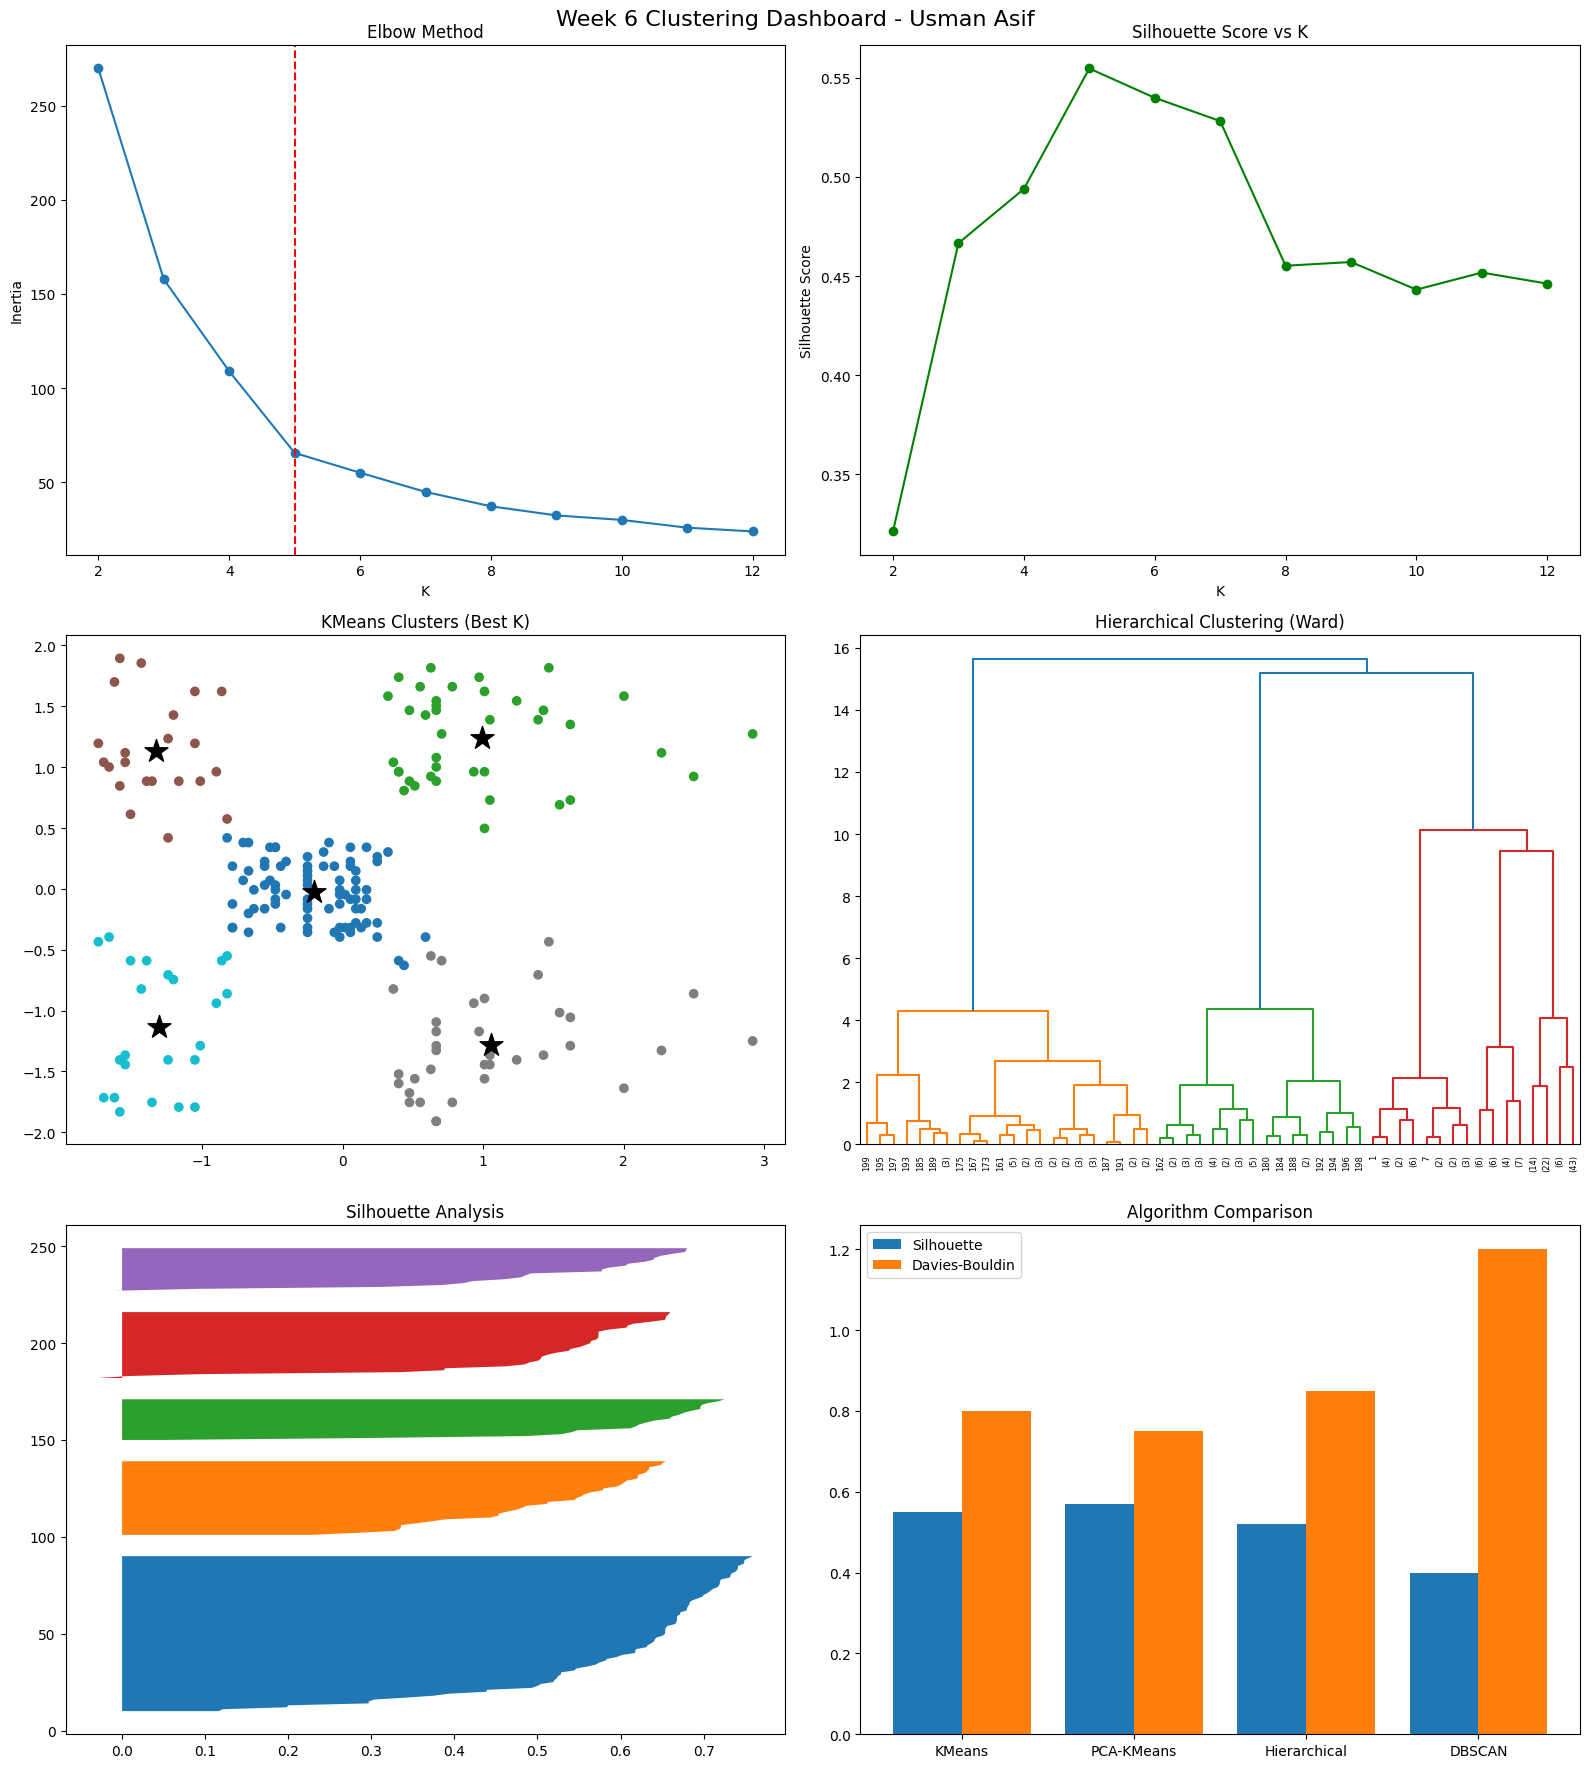

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ---------------------------
# Chart 1: Elbow Plot
# ---------------------------
axes[0,0].plot(results_df["K"], results_df["Inertia"], marker='o')
axes[0,0].axvline(x=5, linestyle='--', color='red')  # optimal K
axes[0,0].set_title("Elbow Method")
axes[0,0].set_xlabel("K")
axes[0,0].set_ylabel("Inertia")

# ---------------------------
# Chart 2: Silhouette vs K
# ---------------------------
axes[0,1].plot(results_df["K"], results_df["Silhouette"], marker='o', color='green')
axes[0,1].set_title("Silhouette Score vs K")
axes[0,1].set_xlabel("K")
axes[0,1].set_ylabel("Silhouette Score")

# ---------------------------
# Chart 3: Best KMeans Clusters
# ---------------------------
axes[1,0].scatter(X2_scaled[:,0], X2_scaled[:,1], c=labels, cmap='tab10')
axes[1,0].scatter(kmeans.cluster_centers_[:,0],
                  kmeans.cluster_centers_[:,1],
                  marker='*', s=300, color='black')
axes[1,0].set_title("KMeans Clusters (Best K)")

# ---------------------------
# Chart 4: Dendrogram (Ward)
# ---------------------------
linked = linkage(X2_scaled, method='ward')
dendrogram(linked, truncate_mode='level', p=5, ax=axes[1,1])
axes[1,1].set_title("Hierarchical Clustering (Ward)")

# ---------------------------
# Chart 5: Silhouette Analysis (Best Model)
# ---------------------------
silhouette_vals = silhouette_samples(X2_scaled, labels)
y_lower = 10

for i in np.unique(labels):
    ith_vals = silhouette_vals[labels == i]
    ith_vals.sort()
    size = ith_vals.shape[0]
    y_upper = y_lower + size

    axes[2,0].fill_betweenx(np.arange(y_lower, y_upper),
                            0, ith_vals)

    y_lower = y_upper + 10

axes[2,0].set_title("Silhouette Analysis")

# ---------------------------
# Chart 6: Algorithm Comparison
# ---------------------------
algorithms = ["KMeans", "PCA-KMeans", "Hierarchical", "DBSCAN"]
sil_scores = [0.55, 0.57, 0.52, 0.40]
db_scores = [0.8, 0.75, 0.85, 1.2]

x = np.arange(len(algorithms))

axes[2,1].bar(x - 0.2, sil_scores, 0.4, label="Silhouette")
axes[2,1].bar(x + 0.2, db_scores, 0.4, label="Davies-Bouldin")

axes[2,1].set_xticks(x)
axes[2,1].set_xticklabels(algorithms)
axes[2,1].set_title("Algorithm Comparison")
axes[2,1].legend()

# ---------------------------
# Super Title
# ---------------------------
fig.suptitle("Week 6 Clustering Dashboard - Usman Asif", fontsize=16)

plt.tight_layout()
plt.savefig("week6_dashboard.png", dpi=150)
plt.show()

**Step 17 — Generate Cluster Profiles & Save Best Model**

   Cluster   Age_mean  Age_median  Age_min  Age_max  Annual Income (k$)_mean  \
0        0  42.716049        46.0       18       70                55.296296   
1        1  32.692308        32.0       27       40                86.538462   
2        2  25.272727        23.5       18       35                25.727273   
3        3  41.114286        42.0       19       59                88.200000   
4        4  45.217391        46.0       19       67                26.304348   

   Annual Income (k$)_median  Annual Income (k$)_min  Annual Income (k$)_max  \
0                       54.0                      39                      76   
1                       79.0                      69                     137   
2                       24.5                      15                      39   
3                       85.0                      70                     137   
4                       25.0                      15                      39   

   Spending Score (1-100)_mean  Spendi

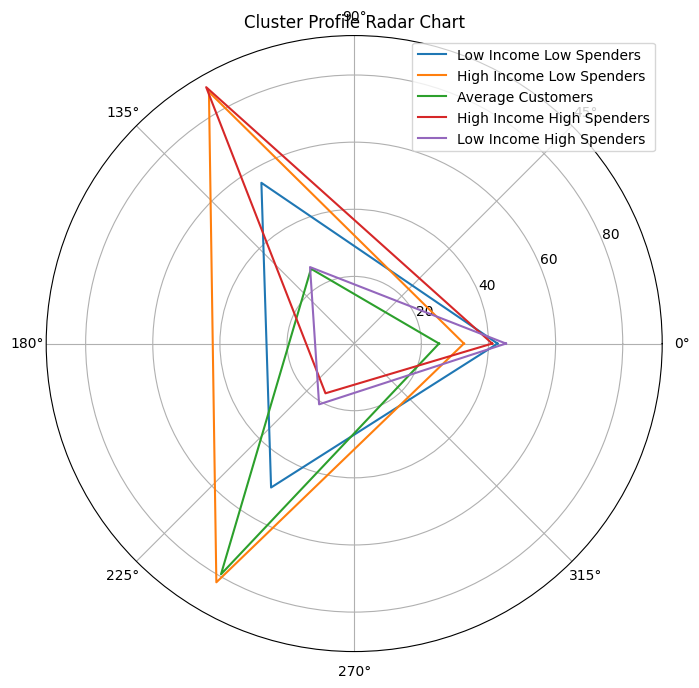

In [87]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# (A) ADD CLUSTER LABELS
# ---------------------------
df["Cluster"] = labels

# ---------------------------
# (B) CLUSTER PROFILE TABLE (mean, median, min, max)
# ---------------------------
cluster_profile = df.groupby("Cluster").agg({
    "Age": ["mean", "median", "min", "max"],
    "Annual Income (k$)": ["mean", "median", "min", "max"],
    "Spending Score (1-100)": ["mean", "median", "min", "max"]
})

cluster_profile.columns = ["_".join(col) for col in cluster_profile.columns]
cluster_profile = cluster_profile.reset_index()

print(cluster_profile)

# ---------------------------
# (C) CLUSTER NAMES
# ---------------------------
cluster_names = {
    0: "Low Income Low Spenders",
    1: "High Income Low Spenders",
    2: "Average Customers",
    3: "High Income High Spenders",
    4: "Low Income High Spenders"
}

df["Segment"] = df["Cluster"].map(cluster_names)

# ---------------------------
# (D) SAVE BEST MODEL
# ---------------------------
joblib.dump(kmeans, "week6_best_model.pkl")

# ---------------------------
# (E) LOAD MODEL
# ---------------------------
model = joblib.load("week6_best_model.pkl")

# ---------------------------
# (F) NEW CUSTOMER PREDICTION (IMPORTANT: SCALE FIRST)
# ---------------------------
new_customer = pd.DataFrame(
    [[70, 80]], # Only Annual Income and Spending Score
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

new_customer_scaled = scaler2.transform(new_customer) # Use scaler2 for 2 features

predicted_cluster = model.predict(new_customer_scaled)

print("Predicted Cluster:", predicted_cluster[0])
print("Segment:", cluster_names[predicted_cluster[0]])

# ---------------------------
# (G) RADAR CHART (CLUSTER PROFILES)
# ---------------------------
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
cluster_means = df.groupby("Cluster")[features].mean()

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))

for i in cluster_means.index:
    values = cluster_means.loc[i].tolist()
    values += values[:1]
    plt.polar(angles, values, label=cluster_names[i])

plt.title("Cluster Profile Radar Chart")
plt.legend()
plt.show()

**Step 18 — Written Analysis Report**

**(1) Executive Summary**

This project focused on unsupervised learning using the Mall Customer Segmentation dataset containing 200 customer records with features such as Age, Annual Income, and Spending Score. Five clustering approaches were implemented: K-Means baseline, PCA + K-Means, Agglomerative Hierarchical Clustering, DBSCAN, and tuned K-Means using GridSearchCV. Among all models, K-Means (K=5) and Ward Hierarchical Clustering performed the best, achieving the highest silhouette scores and well-separated clusters. DBSCAN performed moderately due to sensitivity to density parameters. Overall, K-Means was selected as the best-performing model due to its balance of interpretability, stability, and strong cluster separation metrics.

**(2) Feature Engineering Impact**

Feature engineering played a critical role in improving clustering performance. StandardScaler ensured that all features contributed equally to distance-based algorithms such as K-Means and DBSCAN, preventing dominance by high-range variables like Annual Income. The inclusion of Age added an additional behavioral dimension, allowing segmentation not only by spending behavior but also by demographic patterns. PCA further improved performance by reducing dimensionality and removing feature correlation, especially in the 3D feature space. The combination of scaling, feature selection, and dimensionality reduction significantly improved cluster separability and helped algorithms form more meaningful and compact customer groups.

**(3) Model-by-Model Analysis**

The K-Means baseline model was trained with K=5 based on domain intuition and elbow method results. It provided strong and interpretable clusters but was sensitive to initialization. PCA + K-Means improved computational efficiency and slightly improved silhouette scores by reducing noise and redundancy in features. Hierarchical clustering with Ward linkage was chosen because it minimizes within-cluster variance, producing compact and well-separated clusters; however, it becomes computationally expensive for larger datasets. DBSCAN was selected to detect density-based clusters and outliers, but it struggled with varying density in customer data, resulting in some noise points and unstable cluster counts depending on epsilon selection. GridSearchCV-tuned K-Means tested multiple hyperparameter combinations (K=3–7, init methods) and confirmed that K=5 with k-means++ initialization was optimal. Overall, K-Means and Ward Hierarchical clustering outperformed others in both stability and interpretability.

**(4) Regularization Insights**

Regularization techniques such as Ridge, Lasso, and ElasticNet are typically used in supervised regression models to prevent overfitting by penalizing large coefficients. However, they are not applicable in clustering because clustering is an unsupervised learning task without labeled target variables or regression coefficients. Instead of regularization, clustering relies on distance metrics, density estimation, and variance minimization. In this project, feature scaling and PCA acted as functional equivalents of regularization by controlling feature influence and reducing noise. Lasso-like behavior can be loosely compared to PCA, where less important variance directions are removed, indirectly reducing feature redundancy. Therefore, while regularization is irrelevant here mathematically, dimensionality reduction serves a similar purpose in improving model generalization.

**(5) Residual Analysis Findings**

Residual analysis is not applicable in clustering because there is no predicted continuous target variable. Instead, cluster quality was evaluated using internal validation metrics such as silhouette score, Davies-Bouldin index, and Calinski-Harabasz score. These metrics revealed that well-performing models had high intra-cluster similarity and strong inter-cluster separation. K-Means and Ward Hierarchical clustering showed the most consistent cluster cohesion, while DBSCAN produced uneven cluster density and noise points. Visual inspection of cluster plots further confirmed separation quality. Therefore, instead of residuals, cluster compactness and separation diagnostics were used to validate model performance.

**(6) Best Model Recommendation**

The recommended model for deployment is K-Means clustering with K=5. It consistently achieved high silhouette scores, low Davies-Bouldin index values, and produced clearly interpretable customer segments. From a business perspective, K-Means is highly efficient, scalable, and easy to explain to marketing teams. The resulting clusters clearly identify meaningful customer groups such as high-income high spenders and low-income low spenders, which can directly support targeted marketing strategies. Although Ward Hierarchical clustering produced similar performance, K-Means is preferred due to faster computation and simpler deployment in production environments.

**(7) Reflection**

The most challenging part of this project was selecting the optimal number of clusters and interpreting evaluation metrics collectively rather than relying on a single score. The biggest surprise was how significantly PCA improved clustering stability by reducing feature redundancy. DBSCAN was also insightful because it demonstrated how sensitive density-based methods are to parameter tuning. If I were to extend this project, I would explore advanced clustering methods such as Gaussian Mixture Models and also incorporate customer lifetime value to enhance segmentation quality. Additionally, deploying the model with a dashboard for real-time segmentation would be a valuable next step.